In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nazinan/resume/Enhanced_Resume_Data.csv


In [2]:
!pip install sentence-transformers

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [4]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/nazinan/resume/Enhanced_Resume_Data.csv")

In [5]:
print(df.head())

       Category                                             Resume  \
0  Data Science  Skills * Programming Languages: Python (pandas...   
1  Data Science  Education Details \r\nMay 2013 to May 2017 B.E...   
2  Data Science  Areas of Interest Deep Learning, Control Syste...   
3  Data Science  Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...   
4  Data Science  Education Details \r\n MCA   YMCAUST,  Faridab...   

               name                    email               phone  \
0     Natalie Hayes   xhernandez@example.org  (737)946-9350x4275   
1        James Shaw      david91@example.net          6146611320   
2      Richard Hart  bakerangela@example.org  (926)631-6712x2535   
3  Samuel Wilkinson      qgarner@example.net        618-911-5526   
4      James Adkins  pamelarubio@example.com    955-721-8536x291   

       location  experience  
0     Reyesfort           4  
1    Brooksstad           9  
2     Grayshire           6  
3      Alanbury           6  
4  North Amanda     

In [6]:
print(df.shape)

(962, 7)


In [7]:
print(df.isnull().sum())

Category      0
Resume        0
name          0
email         0
phone         0
location      0
experience    0
dtype: int64


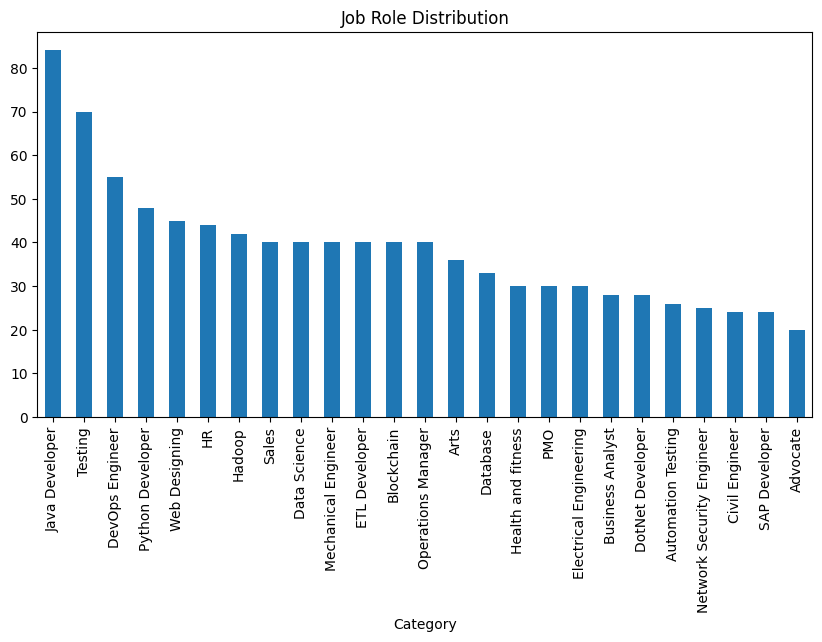

In [8]:
# Category distribution
import matplotlib.pyplot as plt

df['Category'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Job Role Distribution")
plt.show()

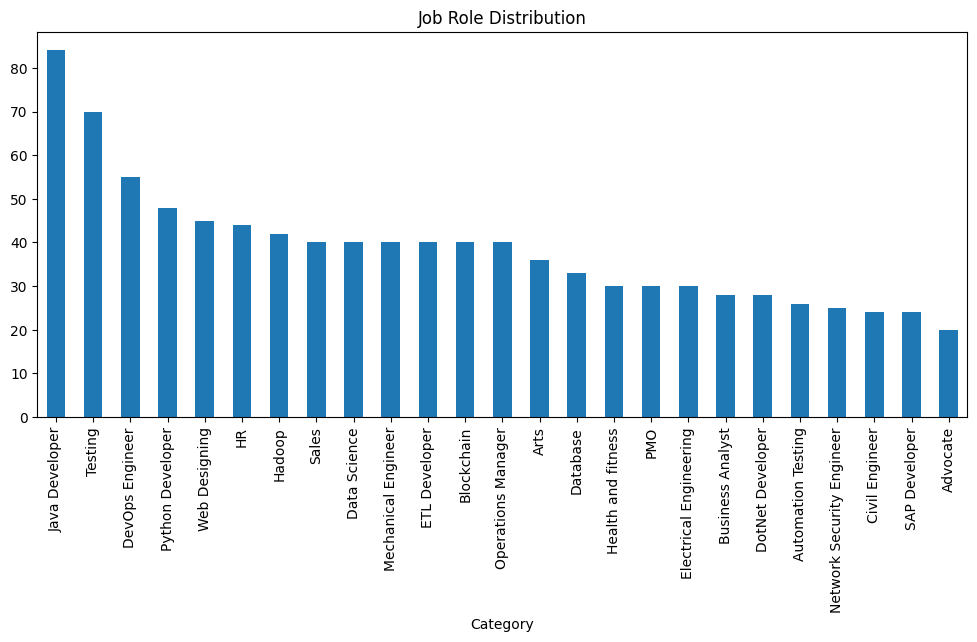

In [9]:
df['Category'].value_counts().plot(kind='bar', figsize=(12,5))
plt.title("Job Role Distribution")
plt.show()

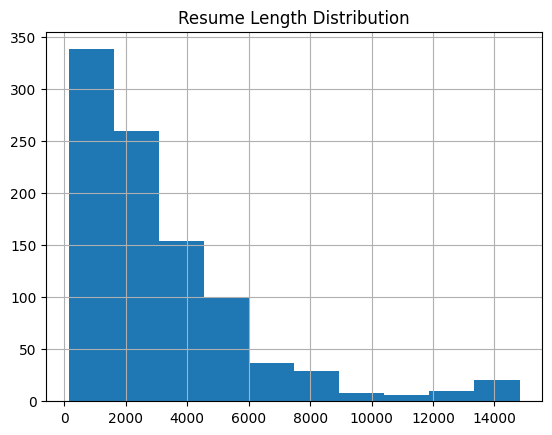

In [10]:
# Resume length
df['resume_length'] = df['Resume'].apply(len)

df['resume_length'].hist()
plt.title("Resume Length Distribution")
plt.show()

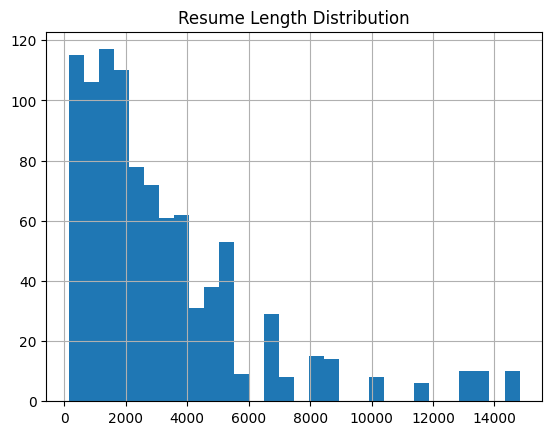

In [11]:
df['resume_length'] = df['Resume'].apply(len)

df['resume_length'].hist(bins=30)
plt.title("Resume Length Distribution")
plt.show()

In [12]:
#create embedding
df['embedding'] = df['Resume'].apply(lambda x: model.encode(x))

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

def semantic_search(query, df, model, top_n=5):
    # Convert query → embedding
    query_embedding = model.encode(query)
    
    # Calculate similarity
    df['score'] = df['embedding'].apply(
        lambda emb: cosine_similarity([query_embedding], [emb])[0][0]
    )
    
    # Sort and return top results
    return df.sort_values(by='score', ascending=False).head(top_n)

In [16]:
# testing it

query = "Looking for Python developer with NLP and ML experience"

results = semantic_search(query, df, model)

results[['name', 'score']].head()

,name,score
0,Natalie Hayes,0.566533
30,Sharon Anderson,0.566533
10,Teresa Jackson,0.566533
20,Robert Carpenter,0.566533
28,Micheal Collins,0.495828
